## 1. Импорты, seed и среда

In [1]:
import random
import re
from dataclasses import dataclass
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"SEED = {SEED}")
print(f"FAISS version: {faiss.__version__}")

SEED = 42
FAISS version: 1.13.2


## 2. База знаний и первичный анализ

In [2]:
BASE_DIR = Path('.')
RAW_DIR = BASE_DIR / 'data' / 'raw'
UPDATE_DIR = BASE_DIR / 'data' / 'update'
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


def load_documents(folder: Path) -> list[dict]:
    docs = []
    for path in sorted(folder.glob('*.txt')):
        raw = path.read_text(encoding='utf-8')
        lines = raw.splitlines()

        title = lines[0].replace('TITLE:', '').strip() if lines and lines[0].startswith('TITLE:') else path.stem
        source_url = lines[1].replace('SOURCE:', '').strip() if len(lines) > 1 and lines[1].startswith('SOURCE:') else ''

        body = '\n'.join(lines[2:]).strip()

        docs.append(
            {
                'doc_id': path.name,
                'title': title,
                'source_url': source_url,
                'text': body,
            }
        )
    return docs


raw_docs = load_documents(RAW_DIR)
update_docs = load_documents(UPDATE_DIR)

print(f"Число документов в основной базе: {len(raw_docs)}")
print(f"Число документов для обновления: {len(update_docs)}")

sample_df = pd.DataFrame(raw_docs)[['doc_id', 'title', 'source_url']].head(5)
sample_df

Число документов в основной базе: 10
Число документов для обновления: 3


,doc_id,title,source_url
0,pandas_001_dataframe_basics.txt,DataFrame basics in pandas,synthetic://pandas/dataframe_basics
1,pandas_002_selection_and_indexing.txt,Selection and indexing,synthetic://pandas/selection_indexing
2,pandas_003_missing_values.txt,Missing values in pandas,synthetic://pandas/missing_values
3,pandas_004_groupby.txt,GroupBy operations,synthetic://pandas/groupby
4,pandas_005_merge_join.txt,Merge and join,synthetic://pandas/merge_join


In [3]:
for doc in raw_docs[:3]:
    print(f"\n=== {doc['doc_id']} | {doc['title']} ===")
    print(doc['text'][:350].replace('\n', ' '), '...')


=== pandas_001_dataframe_basics.txt | DataFrame basics in pandas ===
A pandas DataFrame is a two-dimensional tabular data structure with labeled rows and columns. It is one of the core objects in pandas and is widely used for data analysis and preprocessing. A DataFrame can be created from dictionaries, lists of dictionaries, NumPy arrays, CSV files, Excel files, and many other sources.  Each column in a DataFrame m ...

=== pandas_002_selection_and_indexing.txt | Selection and indexing ===
Selection in pandas can be done with bracket notation, loc, and iloc. Bracket notation is often used for selecting columns, while loc is label-based and iloc is position-based. Using loc, a user can select rows and columns by explicit labels. Using iloc, a user can select data by integer positions.  Boolean masks are also commonly used to filter ro ...

=== pandas_003_missing_values.txt | Missing values in pandas ===
Missing values in pandas are usually represented by NaN, NaT, or pandas nullable m

База знаний относится к одной понятной теме — документации pandas и типовым операциям обработки табличных данных.
По таким документам удобно строить retrieval и mini-RAG, потому что в них содержатся короткие фактические объяснения и определения.

## 3. Чанкинг документов

In [4]:
def split_into_chunks(text: str, chunk_size: int = 520, overlap: int = 80) -> list[str]:
    clean = re.sub(r'\s+', ' ', text).strip()
    if not clean:
        return []

    step = max(1, chunk_size - overlap)
    chunks = []
    start = 0

    while start < len(clean):
        end = min(len(clean), start + chunk_size)
        piece = clean[start:end]

        if end < len(clean):
            last_space = piece.rfind(' ')
            if last_space > int(chunk_size * 0.6):
                end = start + last_space
                piece = clean[start:end]

        piece = piece.strip()
        if piece:
            chunks.append(piece)

        if end >= len(clean):
            break

        next_start = max(start + step, end - overlap)
        if next_start <= start:
            next_start = end
        start = next_start

    return chunks


def build_chunks(documents: list[dict], chunk_size: int, overlap: int) -> pd.DataFrame:
    records = []
    for doc in documents:
        doc_chunks = split_into_chunks(doc['text'], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk_text in enumerate(doc_chunks):
            records.append(
                {
                    'chunk_id': f"{doc['doc_id']}::chunk_{idx:03d}",
                    'doc_id': doc['doc_id'],
                    'title': doc['title'],
                    'chunk_text': chunk_text,
                }
            )
    return pd.DataFrame(records)


CHUNK_SIZE = 520
OVERLAP = 80
chunks_df = build_chunks(raw_docs, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Параметры чанкинга: chunk_size={CHUNK_SIZE}, overlap={OVERLAP}")
print(f"Число чанков (до обновления): {len(chunks_df)}")
chunks_df.head(3)

Параметры чанкинга: chunk_size=520, overlap=80
Число чанков (до обновления): 20


,chunk_id,doc_id,title,chunk_text
0,pandas_001_dataframe_basics.txt::chunk_000,pandas_001_dataframe_basics.txt,DataFrame basics in pandas,A pandas DataFrame is a two-dimensional tabula...
1,pandas_001_dataframe_basics.txt::chunk_001,pandas_001_dataframe_basics.txt,DataFrame basics in pandas,"DataFrame with head, tail, info, describe, col..."
2,pandas_002_selection_and_indexing.txt::chunk_000,pandas_002_selection_and_indexing.txt,Selection and indexing,Selection in pandas can be done with bracket n...


In [5]:
selected_doc = raw_docs[0]
selected_chunks = split_into_chunks(selected_doc['text'], chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Документ: {selected_doc['doc_id']}")
print(f"Получено чанков: {len(selected_chunks)}")
for i, chunk in enumerate(selected_chunks[:3], start=1):
    print(f"\nЧанк {i}:\n{chunk[:320]}...")

Документ: pandas_001_dataframe_basics.txt
Получено чанков: 2

Чанк 1:
A pandas DataFrame is a two-dimensional tabular data structure with labeled rows and columns. It is one of the core objects in pandas and is widely used for data analysis and preprocessing. A DataFrame can be created from dictionaries, lists of dictionaries, NumPy arrays, CSV files, Excel files, and many other sources....

Чанк 2:
DataFrame with head, tail, info, describe, columns, and shape. The index labels rows, while column names label variables. DataFrames support filtering, sorting, aggregation, joins, reshaping, missing-value handling, and time-series operations. This makes pandas convenient for many practical machine learning and analyti...


База знаний относится к одной понятной теме — документации SQLite и типовым операциям работы с SQL-запросами, таблицами, индексами и транзакциями.
По таким документам удобно строить retrieval и mini-RAG, потому что в них содержатся короткие фактические объяснения, определения и примеры команд.

## 4. Векторизация и индекс FAISS

In [6]:
@dataclass
class RetrievalBundle:
    chunks: pd.DataFrame
    vectorizer: TfidfVectorizer
    index: faiss.Index


def build_retrieval_bundle(chunks: pd.DataFrame) -> RetrievalBundle:
    vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(chunks['chunk_text'].tolist())
    embeddings = matrix.toarray().astype(np.float32)
    faiss.normalize_L2(embeddings)

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    return RetrievalBundle(chunks=chunks.reset_index(drop=True), vectorizer=vectorizer, index=index)


def retrieve(query: str, bundle: RetrievalBundle, top_k: int = 3, overfetch: int = 20) -> list[dict]:
    q = bundle.vectorizer.transform([query]).toarray().astype(np.float32)
    faiss.normalize_L2(q)

    fetch_k = min(max(top_k * 3, overfetch), len(bundle.chunks))
    scores, indices = bundle.index.search(q, fetch_k)

    hits = []
    seen_chunk = set()
    for rank_idx, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        row = bundle.chunks.iloc[int(idx)]
        if row['chunk_id'] in seen_chunk:
            continue
        seen_chunk.add(row['chunk_id'])
        hits.append(
            {
                'rank': rank_idx,
                'score': float(score),
                'doc_id': row['doc_id'],
                'chunk_id': row['chunk_id'],
                'chunk_text': row['chunk_text'],
            }
        )
        if len(hits) >= top_k:
            break
    return hits


base_bundle = build_retrieval_bundle(chunks_df)
print(f"Построен индекс FAISS: {base_bundle.index.ntotal} векторов")

Построен индекс FAISS: 20 векторов


In [7]:
example_queries = [
    'What is a DataFrame in pandas?',
    'How does loc differ from iloc?',
    'How can I fill missing values?',
    'How does merge work in pandas?',
    'What are rolling windows?'
]

for q in example_queries:
    hits = retrieve(q, base_bundle, top_k=3)
    print(f"\nЗАПРОС: {q}")
    for h in hits:
        print(f"  rank={h['rank']} score={h['score']:.4f} источник={h['doc_id']}")


ЗАПРОС: What is a DataFrame in pandas?
  rank=1 score=0.3508 источник=pandas_001_dataframe_basics.txt
  rank=2 score=0.1285 источник=pandas_006_sorting_filtering.txt
  rank=3 score=0.1087 источник=pandas_001_dataframe_basics.txt

ЗАПРОС: How does loc differ from iloc?
  rank=1 score=0.3690 источник=pandas_002_selection_and_indexing.txt
  rank=2 score=0.0912 источник=pandas_002_selection_and_indexing.txt
  rank=3 score=0.0000 источник=pandas_010_apply_map.txt

ЗАПРОС: How can I fill missing values?
  rank=1 score=0.6656 источник=pandas_003_missing_values.txt
  rank=2 score=0.2393 источник=pandas_003_missing_values.txt
  rank=3 score=0.0514 источник=pandas_001_dataframe_basics.txt

ЗАПРОС: How does merge work in pandas?
  rank=1 score=0.3337 источник=pandas_005_merge_join.txt
  rank=2 score=0.1755 источник=pandas_005_merge_join.txt
  rank=3 score=0.0446 источник=pandas_010_apply_map.txt

ЗАПРОС: What are rolling windows?
  rank=1 score=0.1005 источник=pandas_008_datetime.txt
  rank=2 sc

## 5. Контрольные запросы и оценка retrieval

In [8]:
def unique_in_order(items):
    out = []
    for x in items:
        if x not in out:
            out.append(x)
    return out


def evaluate_retrieval(queries: list[dict], bundle: RetrievalBundle, top_k: int = 3):
    rows = []
    for item in queries:
        expected_sources = item['expected_sources']
        hits = retrieve(item['query'], bundle, top_k=top_k)
        retrieved_sources = unique_in_order([h['doc_id'] for h in hits])

        intersection = set(retrieved_sources) & set(expected_sources)
        hit_at_k = int(bool(intersection))
        recall_at_k = len(intersection) / len(set(expected_sources))

        rank_of_first = None
        for i, source in enumerate(retrieved_sources, start=1):
            if source in expected_sources:
                rank_of_first = i
                break

        rows.append(
            {
                'query': item['query'],
                'expected_source': ' | '.join(expected_sources),
                'retrieved_sources': ' | '.join(retrieved_sources),
                'hit_at_k': hit_at_k,
                'recall_at_k': round(float(recall_at_k), 4),
                'rank_of_first_relevant': rank_of_first,
            }
        )

    eval_df = pd.DataFrame(rows)
    metrics = {
        'top_k': top_k,
        'hit_at_k': float(eval_df['hit_at_k'].mean()),
        'recall_at_k': float(eval_df['recall_at_k'].mean()),
        'num_queries': int(len(eval_df)),
    }
    return eval_df, metrics


control_queries = [
    {'query': 'What is a DataFrame in pandas?', 'expected_sources': ['pandas_001_dataframe_basics.txt']},
    {'query': 'What is the difference between loc and iloc?', 'expected_sources': ['pandas_002_selection_and_indexing.txt']},
    {'query': 'How can I fill missing values in pandas?', 'expected_sources': ['pandas_003_missing_values.txt']},
    {'query': 'What does groupby do in pandas?', 'expected_sources': ['pandas_004_groupby.txt']},
    {'query': 'How does merge work in pandas?', 'expected_sources': ['pandas_005_merge_join.txt']},
    {'query': 'How do I filter rows with boolean conditions?', 'expected_sources': ['pandas_006_sorting_filtering.txt']},
    {'query': 'What string methods are available through the str accessor?', 'expected_sources': ['pandas_007_string_methods.txt']},
    {'query': 'How do I convert a column to datetime in pandas?', 'expected_sources': ['pandas_008_datetime.txt']},
    {'query': 'What does read_csv do?', 'expected_sources': ['pandas_009_read_write.txt']},
    {'query': 'Why are vectorized operations preferred over apply?', 'expected_sources': ['pandas_010_apply_map.txt']},
]

TOP_K = 3
retrieval_eval_df, retrieval_metrics = evaluate_retrieval(control_queries, base_bundle, top_k=TOP_K)

retrieval_eval_path = ARTIFACTS_DIR / 'retrieval_eval.csv'
retrieval_eval_df.to_csv(retrieval_eval_path, index=False, encoding='utf-8')

print('Метрики retrieval:', retrieval_metrics)
retrieval_eval_df

Метрики retrieval: {'top_k': 3, 'hit_at_k': 1.0, 'recall_at_k': 1.0, 'num_queries': 10}


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,What is a DataFrame in pandas?,pandas_001_dataframe_basics.txt,pandas_001_dataframe_basics.txt | pandas_006_s...,1,1.0,1
1,What is the difference between loc and iloc?,pandas_002_selection_and_indexing.txt,pandas_002_selection_and_indexing.txt | pandas...,1,1.0,1
2,How can I fill missing values in pandas?,pandas_003_missing_values.txt,pandas_003_missing_values.txt | pandas_001_dat...,1,1.0,1
3,What does groupby do in pandas?,pandas_004_groupby.txt,pandas_004_groupby.txt | pandas_010_apply_map....,1,1.0,1
4,How does merge work in pandas?,pandas_005_merge_join.txt,pandas_005_merge_join.txt | pandas_010_apply_m...,1,1.0,1
5,How do I filter rows with boolean conditions?,pandas_006_sorting_filtering.txt,pandas_006_sorting_filtering.txt | pandas_002_...,1,1.0,1
6,What string methods are available through the ...,pandas_007_string_methods.txt,pandas_007_string_methods.txt | pandas_008_dat...,1,1.0,1
7,How do I convert a column to datetime in pandas?,pandas_008_datetime.txt,pandas_008_datetime.txt | pandas_001_dataframe...,1,1.0,1
8,What does read_csv do?,pandas_009_read_write.txt,pandas_009_read_write.txt | pandas_010_apply_m...,1,1.0,1
9,Why are vectorized operations preferred over a...,pandas_010_apply_map.txt,pandas_010_apply_map.txt | pandas_006_sorting_...,1,1.0,1


## 6. Небольшой эксперимент по параметрам retrieval

In [9]:
experiment_rows = []
for candidate_top_k in [1, 3]:
    _, metrics = evaluate_retrieval(control_queries, base_bundle, top_k=candidate_top_k)
    experiment_rows.append(
        {
            'top_k': candidate_top_k,
            'hit_at_k': metrics['hit_at_k'],
            'recall_at_k': metrics['recall_at_k'],
        }
    )

experiment_df = pd.DataFrame(experiment_rows).sort_values('top_k')
experiment_df

,top_k,hit_at_k,recall_at_k
0,1,1.0,1.0
1,3,1.0,1.0


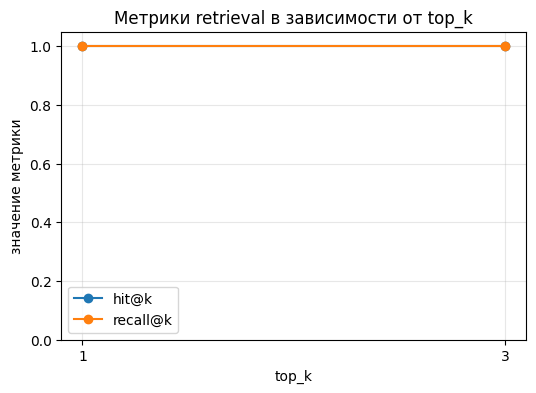

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(experiment_df['top_k'], experiment_df['hit_at_k'], marker='o', label='hit@k')
plt.plot(experiment_df['top_k'], experiment_df['recall_at_k'], marker='o', label='recall@k')
plt.xticks(experiment_df['top_k'])
plt.ylim(0.0, 1.05)
plt.xlabel('top_k')
plt.ylabel('значение метрики')
plt.title('Метрики retrieval в зависимости от top_k')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

В небольшом эксперименте сравниваются два значения `top_k`: 1 и 3.
Ожидаемо, при увеличении `top_k` hit@k и recall@k обычно становятся выше, потому что система получает больше шансов извлечь релевантный источник.

## 7. Обновление базы знаний и переиндексация

In [11]:
updated_docs = raw_docs + update_docs
updated_chunks_df = build_chunks(updated_docs, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
updated_bundle = build_retrieval_bundle(updated_chunks_df)

print(f"Документов после обновления: {len(updated_docs)}")
print(f"Чанков после обновления: {len(updated_chunks_df)}")

Документов после обновления: 13
Чанков после обновления: 23


In [12]:
before_after_queries = [
    'What is a pivot table in pandas?',
    'How do rolling windows work?',
    'What is categorical dtype used for?',
    'How do pivot tables summarize data?',
    'Why would I use rolling mean?',
    'How can categorical dtype reduce memory usage?',
]

before_after_rows = []
for query in before_after_queries:
    before_sources = unique_in_order([h['doc_id'] for h in retrieve(query, base_bundle, top_k=TOP_K)])
    after_sources = unique_in_order([h['doc_id'] for h in retrieve(query, updated_bundle, top_k=TOP_K)])

    before_after_rows.append(
        {
            'query': query,
            'before_retrieved_sources': ' | '.join(before_sources),
            'after_retrieved_sources': ' | '.join(after_sources),
            'changed': str(before_sources != after_sources),
        }
    )

before_after_df = pd.DataFrame(before_after_rows)
before_after_path = ARTIFACTS_DIR / 'retrieval_before_after_update.csv'
before_after_df.to_csv(before_after_path, index=False, encoding='utf-8')

before_after_df

,query,before_retrieved_sources,after_retrieved_sources,changed
0,What is a pivot table in pandas?,pandas_010_apply_map.txt | pandas_001_datafram...,pandas_011_pivot_table.txt | pandas_010_apply_...,True
1,How do rolling windows work?,pandas_008_datetime.txt | pandas_010_apply_map...,pandas_012_rolling_windows.txt | pandas_008_da...,True
2,What is categorical dtype used for?,pandas_003_missing_values.txt | pandas_001_dat...,pandas_013_categorical_data.txt | pandas_003_m...,True
3,How do pivot tables summarize data?,pandas_009_read_write.txt | pandas_005_merge_j...,pandas_011_pivot_table.txt | pandas_013_catego...,True
4,Why would I use rolling mean?,pandas_002_selection_and_indexing.txt | pandas...,pandas_012_rolling_windows.txt | pandas_002_se...,True
5,How can categorical dtype reduce memory usage?,pandas_003_missing_values.txt | pandas_001_dat...,pandas_013_categorical_data.txt | pandas_003_m...,True


После добавления новых документов retrieval начинает возвращать более релевантные источники для запросов,
связанных с pivot tables, rolling windows и categorical data.
Это демонстрирует влияние обновления базы знаний на результат поиска.

In [13]:
def simple_rag_answer(question: str, hits: list[dict]):
    context = ' '.join(hit['chunk_text'] for hit in hits)
    sentences = re.split(r'(?<=[.!?])\s+', context)

    query_terms = set(re.findall(r'[a-zA-Z0-9_]+', question.lower()))
    scored = []
    for sentence in sentences:
        sent = sentence.strip()
        if not sent:
            continue
        sent_terms = set(re.findall(r'[a-zA-Z0-9_]+', sent.lower()))
        overlap = len(query_terms & sent_terms)
        scored.append((overlap, sent))

    scored.sort(key=lambda x: x[0], reverse=True)
    best = [s for _, s in scored[:2]]
    answer = ' '.join(best) if best else 'Not enough relevant context in the knowledge base.'

    sources = unique_in_order([hit['doc_id'] for hit in hits])
    return answer, sources


rag_questions = [
    'What is the difference between loc and iloc?',
    'How should I handle missing values in pandas?',
    'When should I use merge?',
    'What are rolling windows used for?',
    'Why are vectorized operations preferred over apply?'
]

rag_rows = []
for question in rag_questions:
    hits = retrieve(question, updated_bundle, top_k=TOP_K)
    answer, sources = simple_rag_answer(question, hits)
    rag_rows.append(
        {
            'question': question,
            'answer': answer,
            'retrieved_sources': ' | '.join(sources),
        }
    )

rag_df = pd.DataFrame(rag_rows)
rag_examples_path = ARTIFACTS_DIR / 'rag_examples.csv'
rag_df.to_csv(rag_examples_path, index=False, encoding='utf-8')

rag_df

,question,answer,retrieved_sources
0,What is the difference between loc and iloc?,Bracket notation is often used for selecting c...,pandas_002_selection_and_indexing.txt | pandas...
1,How should I handle missing values in pandas?,Missing values in pandas are usually represent...,pandas_003_missing_values.txt | pandas_011_piv...
2,When should I use merge?,"When modifying data, it is usually safer to us...",pandas_005_merge_join.txt | pandas_002_selecti...
3,What are rolling windows used for?,Rolling window operations compute statistics o...,pandas_012_rolling_windows.txt | pandas_008_da...
4,Why are vectorized operations preferred over a...,Vectorized operations are generally preferred ...,pandas_010_apply_map.txt | pandas_006_sorting_...


## 9. Краткий анализ ошибок (3-5 примеров mini-RAG)

In [14]:
analysis_questions = [
    'What are rolling windows and how are they different from ordinary aggregates?',
    'Does pivot_table replace groupby in every case?',
    'How can categorical dtype help in large tables?',
    'How are missing values handled in mixed-type DataFrames?',
]

for q in analysis_questions:
    hits = retrieve(q, updated_bundle, top_k=TOP_K)
    answer, sources = simple_rag_answer(q, hits)
    print(f"\nВопрос: {q}")
    print(f"Источники: {sources}")
    print(f"Ответ: {answer[:350]}...")


Вопрос: What are rolling windows and how are they different from ordinary aggregates?
Источники: ['pandas_012_rolling_windows.txt', 'pandas_006_sorting_filtering.txt', 'pandas_008_datetime.txt']
Ответ: Rolling window operations compute statistics over moving windows of observations. Common examples include rolling mean, rolling sum, and rolling standard deviation....

Вопрос: Does pivot_table replace groupby in every case?
Источники: ['pandas_011_pivot_table.txt', 'pandas_007_string_methods.txt', 'pandas_004_groupby.txt']
Ответ: They can often replace more verbose groupby plus reshape workflows. These methods allow users to lower-case text, strip spaces, match patterns, replace substrings, and split text....

Вопрос: How can categorical dtype help in large tables?
Источники: ['pandas_013_categorical_data.txt', 'pandas_005_merge_join.txt', 'pandas_011_pivot_table.txt']
Ответ: Categorical dtype in pandas represents repeated values from a fixed set of categories. It is often beneficial w

### Комментарии по пограничным случаям
- Вопросы про rolling windows могут смешивать контекст из time-series операций и общих aggregate-описаний.
- Вопросы про pivot_table и groupby иногда извлекают соседние по смыслу документы, потому что темы частично пересекаются.
- Вопросы про missing values в смешанных таблицах могут собирать сразу несколько стратегий обработки, из-за чего ответ получается обобщённым.
- Простой extractive-генератор воспроизводим и прозрачен, но он слабее полноценной генеративной модели, которая умеет аккуратно синтезировать ответ по нескольким источникам.